<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-7-Three_Nonlinear_Hamiltonian%20Systems/Untitled194.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Euler's Collinear Solution**

Another remarkable periodic solution of the three-body problem was discovered by Euler in 1767. In this configuration the three bodies remain collinear throughout the motion while the entire configuration rotates rigidly around the center of mass with constant angular velocity.

Euler's solution constrains all bodies to lie on the same straight line at every instant of time. The relative distances between the bodies remain constant, and the configuration behaves as a rotating rigid system.

In the next code we learn parameters $a, b, \omega$.

0 17.967892 0.2499 -0.9999 0.3001
500 11.247913 0.2037187 -0.95520973 0.35427585
1000 5.5115786 0.1680379 -0.9275893 0.40581158
1500 2.3472621 0.1427169 -0.92112374 0.44619685
2000 1.0768784 0.12456967 -0.9318404 0.4738678
2500 0.66657823 0.11022298 -0.9514041 0.48980874
3000 0.54276156 0.09765654 -0.9739429 0.49687505
3500 0.47720385 0.08628322 -0.99750245 0.4990339
4000 0.42638138 0.07613483 -1.0218966 0.49943334
4500 0.38502115 0.06736278 -1.0472062 0.49947086
5000 0.35097018 0.06006875 -1.0735004 0.49947122
5500 0.31620553 0.05427798 -1.1007915 0.49947163
6000 0.29070497 0.049932137 -1.1290237 0.499472
6500 0.2668993 0.04688622 -1.1581526 0.4994722
7000 0.23944694 0.044939272 -1.1880621 0.49947244
7500 0.22394475 0.043858897 -1.21861 0.4994726
8000 0.20888674 0.04340215 -1.2496946 0.4994727
8500 0.19038935 0.043346748 -1.2812362 0.49947277
9000 0.17767146 0.043505892 -1.3131363 0.49947286
9500 0.16527921 0.043729182 -1.3453046 0.49947295
10000 0.15386291 0.043899536 -1.3776561 0.49

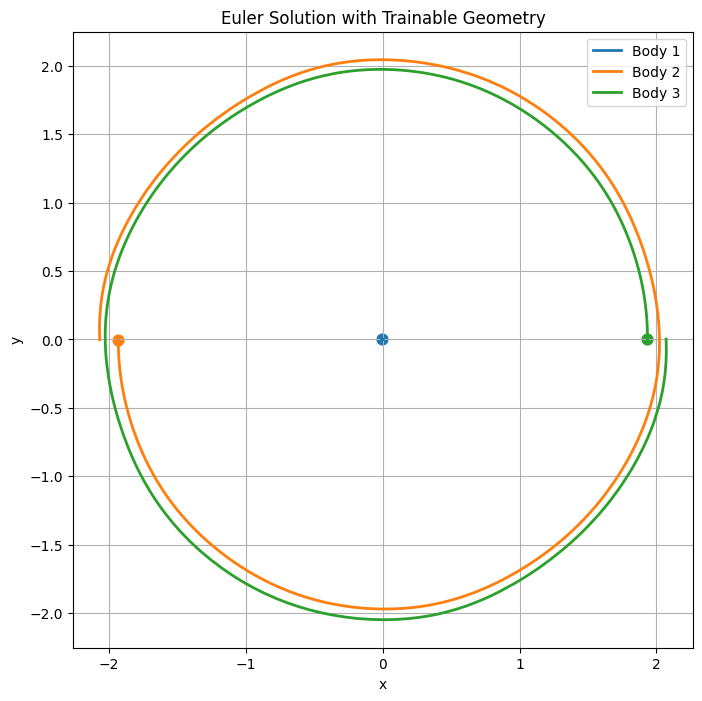

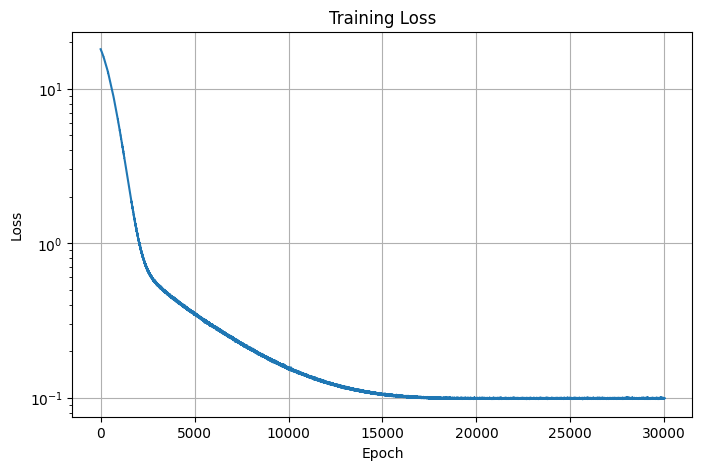

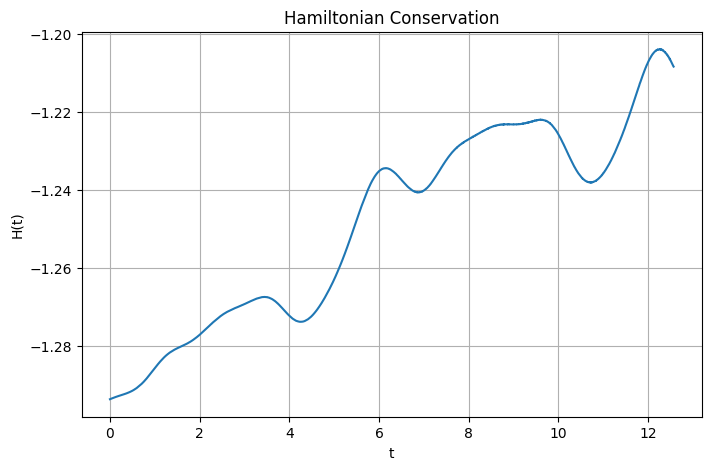

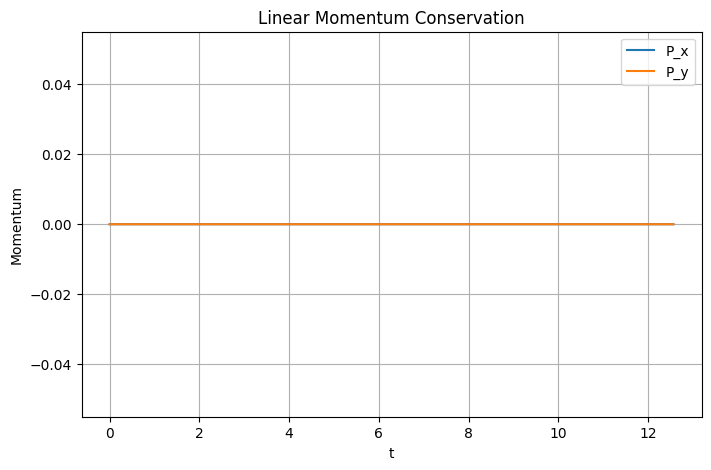

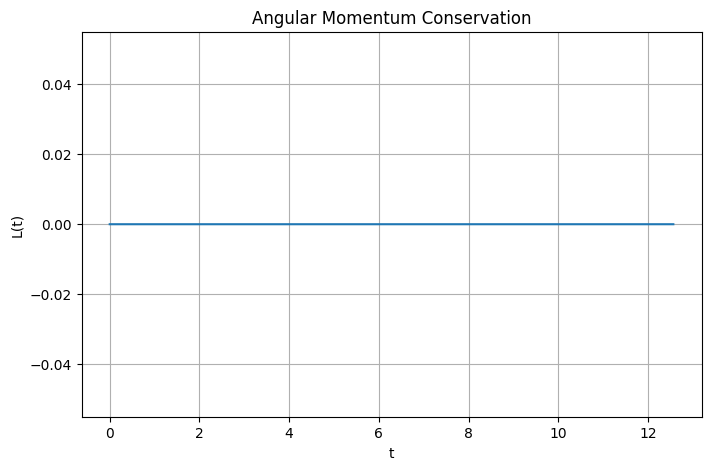

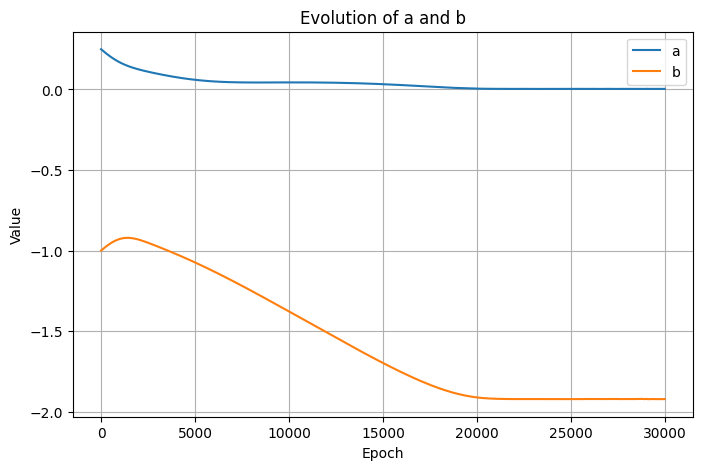

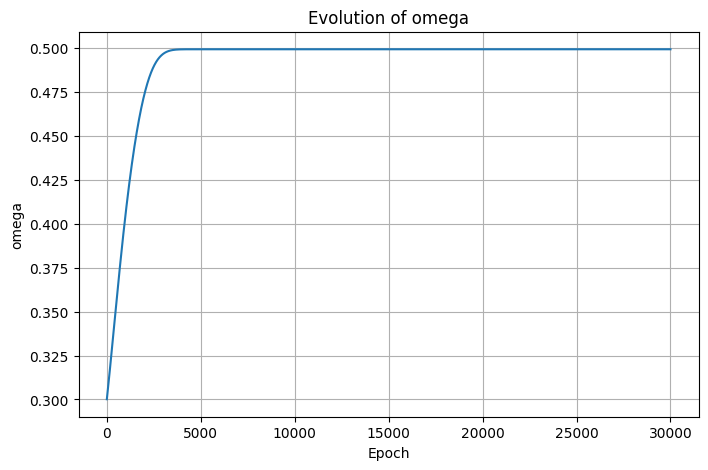


Final learned parameters:

a = 0.0037089915
b = -1.9214661
omega = 0.4994737

Central configuration:

lambda1 = -0.0037089915
lambda2 = -1.9214661
lambda3 = 1.9251751


In [ ]:
# ============================================================
# GEOMETRIC REDUCED PINN
# EULER THREE-BODY PROBLEM
#
# TRAINABLE:
#
#   rho(t)
#   theta(t)
#   a
#   b
#   omega
#
# ============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import scipy.optimize

# ============================================================
# FLOAT TYPE
# ============================================================

tf.keras.backend.set_floatx('float32')

# ============================================================
# PARAMETERS
# ============================================================

G = 1.0

Tmax = 4.0*np.pi

epochs = 30000

lr = 1e-4

Ncol = 128

# ============================================================
# FOURIER FEATURES
# ============================================================

class FourierLayer(tf.keras.layers.Layer):

    def __init__(self,freqs):

        super().__init__()

        self.freqs = freqs

    def call(self,t):

        features = [t]

        for k in self.freqs:

            features.append(tf.sin(k*t))
            features.append(tf.cos(k*t))

        return tf.concat(features,axis=1)

# ============================================================
# MODEL
# ============================================================

class EulerReducedPINN(tf.keras.Model):

    def __init__(self):

        super().__init__()

        # ====================================================
        # TRAINABLE GEOMETRIC PARAMETERS
        # ====================================================

        self.a = tf.Variable(
            0.25,
            trainable=True,
            dtype=tf.float32
        )

        self.b = tf.Variable(
            -1,
            trainable=True,
            dtype=tf.float32
        )

        # ====================================================
        # TRAINABLE OMEGA
        # ====================================================

        self.omega = tf.Variable(
            0.3,
            trainable=True,
            dtype=tf.float32
        )

        # ====================================================

        self.fourier = FourierLayer(
            [1,2,3]
        )

        self.hidden1 = tf.keras.layers.Dense(
            128,
            activation='swish'
        )

        self.hidden2 = tf.keras.layers.Dense(
            128,
            activation='swish'
        )

        self.hidden3 = tf.keras.layers.Dense(
            128,
            activation='swish'
        )

        self.hidden4 = tf.keras.layers.Dense(
            128,
            activation='swish'
        )

        # ====================================================
        # OUTPUTS:
        #
        # rho correction
        # theta correction
        # ====================================================

        self.out = tf.keras.layers.Dense(2)

    # ========================================================

    def call(self,t):

        # ====================================================
        # CENTRAL CONFIGURATION
        # ====================================================

        lambda1 = -self.a

        lambda2 = self.b

        lambda3 = self.a - self.b

        # ====================================================

        z = self.fourier(t)

        z = self.hidden1(z)
        z = self.hidden2(z)
        z = self.hidden3(z)
        z = self.hidden4(z)

        raw = self.out(z)

        # ====================================================
        # POSITIVE RADIAL FUNCTION
        # ====================================================

        rho = tf.exp(
            0.3*raw[:,0:1]
        )

        # ====================================================
        # ANGLE FUNCTION
        # ====================================================

        theta = (

            self.omega*t

            +

            0.05*raw[:,1:2]

        )

        # ====================================================
        # ROTATION MATRIX
        # ====================================================

        c = tf.cos(theta)
        s = tf.sin(theta)

        # ====================================================
        # BODY 1
        # ====================================================

        q1x = rho*lambda1*c
        q1y = rho*lambda1*s

        # ====================================================
        # BODY 2
        # ====================================================

        q2x = rho*lambda2*c
        q2y = rho*lambda2*s

        # ====================================================
        # BODY 3
        # ====================================================

        q3x = rho*lambda3*c
        q3y = rho*lambda3*s

        # ====================================================
        # STACK
        # ====================================================

        q1 = tf.concat(
            [q1x,q1y],
            axis=1
        )

        q2 = tf.concat(
            [q2x,q2y],
            axis=1
        )

        q3 = tf.concat(
            [q3x,q3y],
            axis=1
        )

        q = tf.stack(
            [q1,q2,q3],
            axis=1
        )

        return q

# ============================================================
# MODEL
# ============================================================

model = EulerReducedPINN()

# ============================================================
# TRAINABLE VARIABLES
# ============================================================

train_vars = (

    model.trainable_variables

    +

    [
        model.a,
        model.b,
        model.omega
    ]

)

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = tf.keras.optimizers.Adam(lr)

# ============================================================
# HAMILTONIAN
# ============================================================

def compute_hamiltonian(q,p):

    kinetic = 0.5*tf.reduce_sum(
        p**2,
        axis=[1,2]
    )

    potential = 0.0

    for i in range(3):

        for j in range(i+1,3):

            rij = q[:,i,:]-q[:,j,:]

            dist = tf.sqrt(
                tf.reduce_sum(
                    rij**2,
                    axis=1
                ) + 1e-6
            )

            potential += -G/dist

    return kinetic + potential

# ============================================================
# LINEAR MOMENTUM
# ============================================================

def linear_momentum(p):

    return tf.reduce_sum(
        p,
        axis=1
    )

# ============================================================
# ANGULAR MOMENTUM
# ============================================================

def angular_momentum(q,p):

    x = q[:,:,0]
    y = q[:,:,1]

    px = p[:,:,0]
    py = p[:,:,1]

    return tf.reduce_sum(
        x*py - y*px,
        axis=1
    )

# ============================================================
# LOSS FUNCTION
# ============================================================

@tf.function

def compute_loss(t):

    with tf.GradientTape(
        persistent=True
    ) as tape2:

        tape2.watch(t)

        with tf.GradientTape(
            persistent=True
        ) as tape1:

            tape1.watch(t)

            q = model(t)

        qx = q[:,:,0]
        qy = q[:,:,1]

        dqx_dt = tape1.batch_jacobian(
            qx,
            t
        )[:,:,0]

        dqy_dt = tape1.batch_jacobian(
            qy,
            t
        )[:,:,0]

        p = tf.stack(
            [dqx_dt,dqy_dt],
            axis=2
        )

    # ========================================================
    # SECOND DERIVATIVES
    # ========================================================

    dpx_dt = tape2.batch_jacobian(
        p[:,:,0],
        t
    )[:,:,0]

    dpy_dt = tape2.batch_jacobian(
        p[:,:,1],
        t
    )[:,:,0]

    del tape1
    del tape2

    dp_dt = tf.stack(
        [dpx_dt,dpy_dt],
        axis=2
    )

    # ========================================================
    # FORCES
    # ========================================================

    forces = []

    for i in range(3):

        Fi = 0.0

        for j in range(3):

            if i != j:

                rij = q[:,j,:]-q[:,i,:]

                dist = tf.sqrt(
                    tf.reduce_sum(
                        rij**2,
                        axis=1,
                        keepdims=True
                    ) + 1e-6
                )

                Fi += G*rij/(dist**3)

        forces.append(Fi)

    forces = tf.stack(
        forces,
        axis=1
    )

    # ========================================================
    # PHYSICS LOSS
    # ========================================================

    residual = dp_dt - forces

    loss_phys = tf.reduce_mean(
        residual**2
    )

    # ========================================================
    # HAMILTONIAN LOSS
    # ========================================================

    H = compute_hamiltonian(q,p)

    loss_H = tf.reduce_mean(
        (H-H[0])**2
    )

    # ========================================================
    # MOMENTUM LOSS
    # ========================================================

    P = linear_momentum(p)

    loss_P = tf.reduce_mean(
        P**2
    )

    # ========================================================
    # ANGULAR MOMENTUM LOSS
    # ========================================================

    L = angular_momentum(q,p)

    loss_L = tf.reduce_mean(
        (L-L[0])**2
    )

    # ========================================================
    # PERIODICITY LOSS
    # ========================================================

    q0 = model(
        tf.constant([[0.0]])
    )

    qT = model(
        tf.constant([[Tmax]])
    )

    loss_periodic = tf.reduce_mean(
        (q0-qT)**2
    )

    # ========================================================
    # REGULARIZATION
    # ========================================================

    reg = 0.001*(
        model.a**2
        +
        model.b**2
        +
        model.omega**2
    )

    # ========================================================
    # TOTAL LOSS
    # ========================================================

    total_loss = (

        loss_phys

        +

        0.5*loss_H

        +

        0.1*loss_P

        +

        0.1*loss_L

        +

        10.0*loss_periodic

        +

        reg

    )

    return total_loss

# ============================================================
# TRAIN STEP
# ============================================================

@tf.function

def train_step():

    t_batch = tf.random.uniform(
        (Ncol,1),
        0.0,
        Tmax
    )

    with tf.GradientTape() as tape:

        loss = compute_loss(t_batch)

    grads = tape.gradient(
        loss,
        train_vars
    )

    optimizer.apply_gradients(
        zip(
            grads,
            train_vars
        )
    )

    return loss

# ============================================================
# TRAINING
# ============================================================

loss_history = []

a_history = []

b_history = []

omega_history = []

for epoch in range(epochs):

    loss = train_step()

    loss_history.append(
        loss.numpy()
    )

    a_history.append(
        model.a.numpy()
    )

    b_history.append(
        model.b.numpy()
    )

    omega_history.append(
        model.omega.numpy()
    )

    if epoch % 500 == 0:

        print(
            epoch,
            loss.numpy(),
            model.a.numpy(),
            model.b.numpy(),
            model.omega.numpy()
        )

# ============================================================
# EVALUATION
# ============================================================

t_test = tf.linspace(
    0.0,
    Tmax,
    4000
)

t_test = tf.reshape(
    t_test,
    (-1,1)
)

# ============================================================

with tf.GradientTape(
    persistent=True
) as tape:

    tape.watch(t_test)

    q_pred = model(t_test)

qx = q_pred[:,:,0]
qy = q_pred[:,:,1]

dqx_dt = tape.batch_jacobian(
    qx,
    t_test
)[:,:,0]

dqy_dt = tape.batch_jacobian(
    qy,
    t_test
)[:,:,0]

del tape

p_pred = tf.stack(
    [dqx_dt,dqy_dt],
    axis=2
)

# ============================================================

q_pred = q_pred.numpy()

p_pred = p_pred.numpy()

t_np = t_test.numpy().flatten()

# ============================================================
# CONSERVED QUANTITIES
# ============================================================

H_pred = compute_hamiltonian(

    tf.constant(q_pred,dtype=tf.float32),
    tf.constant(p_pred,dtype=tf.float32)

).numpy()

P_pred = linear_momentum(

    tf.constant(p_pred,dtype=tf.float32)

).numpy()

L_pred = angular_momentum(

    tf.constant(q_pred,dtype=tf.float32),
    tf.constant(p_pred,dtype=tf.float32)

).numpy()

# ============================================================
# TRAJECTORIES
# ============================================================

plt.figure(figsize=(8,8))

for i in range(3):

    plt.plot(
        q_pred[:,i,0],
        q_pred[:,i,1],
        linewidth=2,
        label=f'Body {i+1}'
    )

    plt.scatter(
        q_pred[0,i,0],
        q_pred[0,i,1],
        s=60
    )

plt.xlabel('x')
plt.ylabel('y')

plt.title(
    'Euler Solution with Trainable Geometry'
)

plt.legend()

plt.grid()

plt.axis('equal')

plt.show()

# ============================================================
# LOSS
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.yscale('log')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Training Loss')

plt.grid()

plt.show()

# ============================================================
# HAMILTONIAN
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    t_np,
    H_pred
)

plt.xlabel('t')
plt.ylabel('H(t)')

plt.title(
    'Hamiltonian Conservation'
)

plt.grid()

plt.show()

# ============================================================
# LINEAR MOMENTUM
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    t_np,
    P_pred[:,0],
    label='P_x'
)

plt.plot(
    t_np,
    P_pred[:,1],
    label='P_y'
)

plt.xlabel('t')
plt.ylabel('Momentum')

plt.title(
    'Linear Momentum Conservation'
)

plt.legend()

plt.grid()

plt.show()

# ============================================================
# ANGULAR MOMENTUM
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    t_np,
    L_pred
)

plt.xlabel('t')
plt.ylabel('L(t)')

plt.title(
    'Angular Momentum Conservation'
)

plt.grid()

plt.show()

# ============================================================
# a,b EVOLUTION
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    a_history,
    label='a'
)

plt.plot(
    b_history,
    label='b'
)

plt.xlabel('Epoch')
plt.ylabel('Value')

plt.title(
    'Evolution of a and b'
)

plt.legend()

plt.grid()

plt.show()

# ============================================================
# OMEGA EVOLUTION
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    omega_history
)

plt.xlabel('Epoch')
plt.ylabel('omega')

plt.title(
    'Evolution of omega'
)

plt.grid()

plt.show()

# ============================================================
# FINAL PARAMETERS
# ============================================================

print("\nFinal learned parameters:\n")

print("a =",model.a.numpy())

print("b =",model.b.numpy())

print("omega =",model.omega.numpy())

print("\nCentral configuration:\n")

print("lambda1 =",-model.a.numpy())

print("lambda2 =",model.b.numpy())

print("lambda3 =",model.a.numpy()-model.b.numpy())

In the next code we assume known values $a=0$, $b=-2$ and $\omega=0.5$. We obtain a better energy diagnosis than before.

0 0.03179474
500 0.0011924838
1000 0.00023778604
1500 8.376806e-05
2000 4.9274542e-05
2500 3.32786e-05
3000 2.0437179e-05
3500 1.4758941e-05
4000 1.721929e-05
4500 8.039207e-06
5000 9.235768e-06
5500 4.646767e-06
6000 3.8591147e-06
6500 2.6866653e-06
7000 2.3122066e-06
7500 1.6982341e-06
8000 1.2542201e-06
8500 1.2421303e-06
9000 8.3140304e-07
9500 6.9025043e-07
10000 5.4145147e-07
10500 5.1443016e-07
11000 3.6676343e-07
11500 1.9361287e-06
12000 2.8771524e-07
12500 2.514191e-07
13000 2.0717005e-07
13500 2.0151363e-07
14000 1.396005e-07
14500 1.2991916e-07
15000 1.04081046e-07
15500 1.146564e-07
16000 8.102862e-08
16500 7.299864e-08
17000 7.042655e-08
17500 5.860537e-08
18000 5.4346593e-08
18500 5.0684278e-08
19000 4.8765227e-08
19500 5.099542e-08
20000 3.7776278e-08
20500 3.8075303e-08
21000 3.6788286e-08
21500 3.3513423e-08
22000 3.001396e-08
22500 2.810537e-08
23000 2.8271357e-08
23500 2.7841494e-08
24000 2.4212587e-08
24500 2.5350039e-08
25000 2.3419538e-08
25500 2.1674472e-08
2600

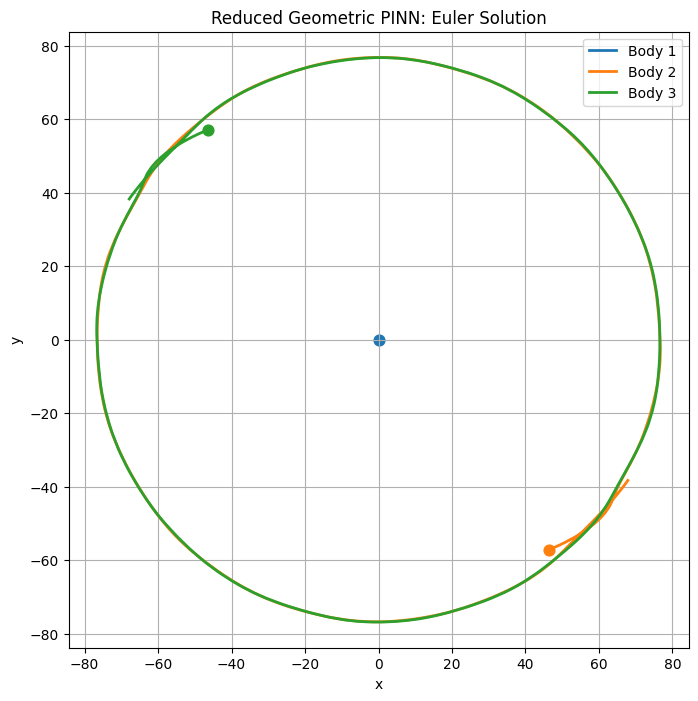

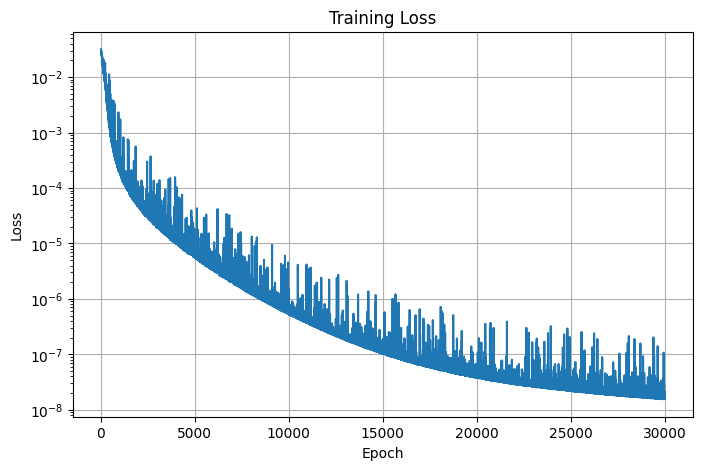

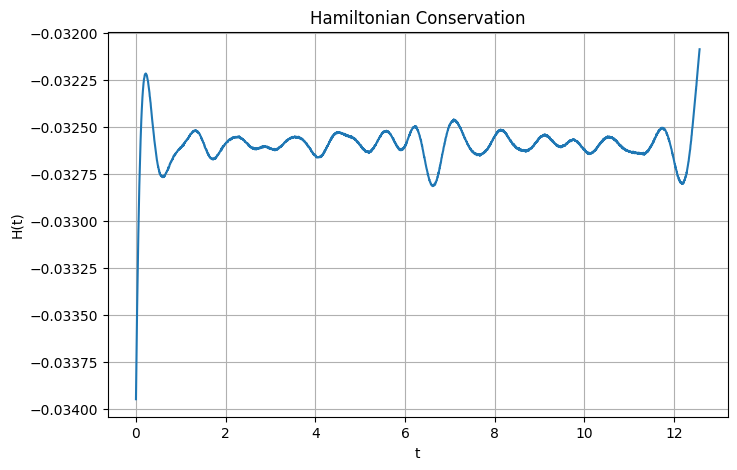

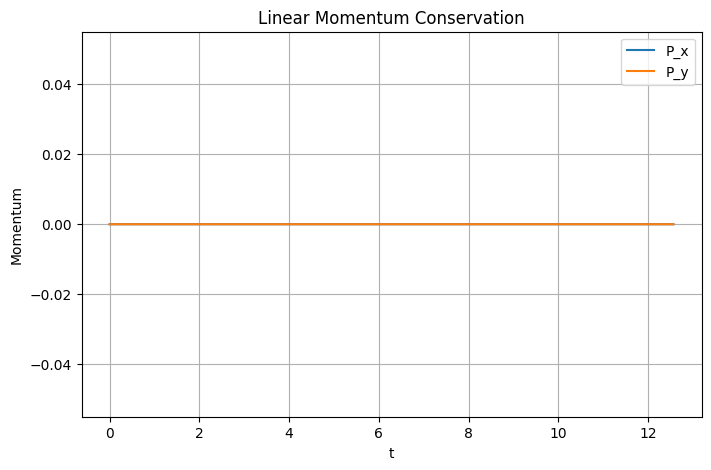

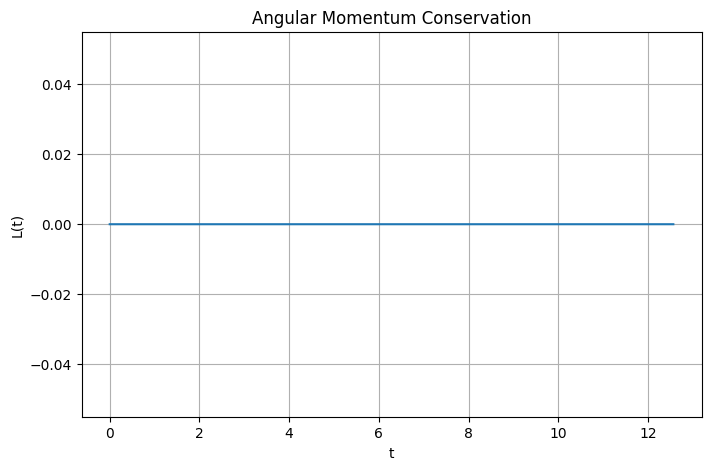

In [ ]:
# ============================================================
# IDEAL REDUCED GEOMETRIC PINN
# EULER COLLINEAR THREE-BODY SOLUTION
# ============================================================
#
# Main idea:
#
# Instead of learning all coordinates independently,
# the network learns ONLY:
#
#   rho(t)     -> radial scaling
#   theta(t)   -> rotation angle
#
# and reconstructs:
#
# q_i(t)=rho(t) R(theta(t)) (lambda_i,0)
#
# This guarantees:
#
# - exact collinearity
# - exact similarity
# - exact geometric reduction
#
# ============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import scipy.optimize

# ============================================================
# FLOAT TYPE
# ============================================================

tf.keras.backend.set_floatx('float32')

# ============================================================
# PARAMETERS
# ============================================================

G = 1.0

m1 = m2 = m3 = 1.0

# ============================================================
# COLLINEAR CONFIGURATION
# ============================================================



lambda1 = 0
lambda2 = -2
lambda3 = 2

# ============================================================
# ANGULAR VELOCITY
# ============================================================

omega0 = 0.5

# ============================================================
# TIME INTERVAL
# ============================================================

Tmax = 4.0*np.pi

# ============================================================
# COLLOCATION
# ============================================================

Ncol = 128

epochs = 30000

lr = 1e-4

# ============================================================
# FOURIER FEATURES
# ============================================================

class FourierLayer(tf.keras.layers.Layer):

    def __init__(self,freqs):

        super().__init__()

        self.freqs = freqs

    def call(self,t):

        features = [t]

        for k in self.freqs:

            features.append(tf.sin(k*t))
            features.append(tf.cos(k*t))

        return tf.concat(features,axis=1)

# ============================================================
# REDUCED MODEL
# ============================================================

class ReducedEulerPINN(tf.keras.Model):

    def __init__(self):

        super().__init__()

        self.fourier = FourierLayer(
            [1,2,3,4,5]
        )

        self.hidden1 = tf.keras.layers.Dense(
            128,
            activation='swish'
        )

        self.hidden2 = tf.keras.layers.Dense(
            128,
            activation='swish'
        )

        self.hidden3 = tf.keras.layers.Dense(
            128,
            activation='swish'
        )

        self.hidden4 = tf.keras.layers.Dense(
            128,
            activation='swish'
        )

        # outputs:
        #
        # rho correction
        # theta correction

        self.out = tf.keras.layers.Dense(2)

    # ========================================================

    def call(self,t):

        z = self.fourier(t)

        z = self.hidden1(z)
        z = self.hidden2(z)
        z = self.hidden3(z)
        z = self.hidden4(z)

        raw = self.out(z)

        # ====================================================
        # RADIAL FUNCTION
        # ====================================================

        rho = (

            1.0

            +

            0.05*raw[:,0:1]

        )

        # ====================================================
        # ANGLE FUNCTION
        # ====================================================

        theta = (

            omega0*t

            +

            0.05*raw[:,1:2]

        )

        # ====================================================
        # ROTATION MATRIX
        # ====================================================

        c = tf.cos(theta)
        s = tf.sin(theta)

        # ====================================================
        # BODY 1
        # ====================================================

        q1x = rho*lambda1*c
        q1y = rho*lambda1*s

        # ====================================================
        # BODY 2
        # ====================================================

        q2x = rho*lambda2*c
        q2y = rho*lambda2*s

        # ====================================================
        # BODY 3
        # ====================================================

        q3x = rho*lambda3*c
        q3y = rho*lambda3*s

        # ====================================================
        # STACK
        # ====================================================

        q1 = tf.concat(
            [q1x,q1y],
            axis=1
        )

        q2 = tf.concat(
            [q2x,q2y],
            axis=1
        )

        q3 = tf.concat(
            [q3x,q3y],
            axis=1
        )

        q = tf.stack(
            [q1,q2,q3],
            axis=1
        )

        return q

# ============================================================
# MODEL
# ============================================================

model = ReducedEulerPINN()

optimizer = tf.keras.optimizers.Adam(lr)

# ============================================================
# HAMILTONIAN
# ============================================================

def compute_hamiltonian(q,p):

    kinetic = 0.5*tf.reduce_sum(
        p**2,
        axis=[1,2]
    )

    potential = 0.0

    for i in range(3):

        for j in range(i+1,3):

            rij = q[:,i,:]-q[:,j,:]

            dist = tf.sqrt(
                tf.reduce_sum(
                    rij**2,
                    axis=1
                ) + 1e-6
            )

            potential += -G/dist

    return kinetic + potential

# ============================================================
# LINEAR MOMENTUM
# ============================================================

def linear_momentum(p):

    return tf.reduce_sum(
        p,
        axis=1
    )

# ============================================================
# ANGULAR MOMENTUM
# ============================================================

def angular_momentum(q,p):

    x = q[:,:,0]
    y = q[:,:,1]

    px = p[:,:,0]
    py = p[:,:,1]

    return tf.reduce_sum(
        x*py - y*px,
        axis=1
    )

# ============================================================
# LOSS FUNCTION
# ============================================================

@tf.function

def compute_loss(t):

    with tf.GradientTape(
        persistent=True
    ) as tape2:

        tape2.watch(t)

        with tf.GradientTape(
            persistent=True
        ) as tape1:

            tape1.watch(t)

            q = model(t)

        qx = q[:,:,0]
        qy = q[:,:,1]

        dqx_dt = tape1.batch_jacobian(
            qx,
            t
        )[:,:,0]

        dqy_dt = tape1.batch_jacobian(
            qy,
            t
        )[:,:,0]

        p = tf.stack(
            [dqx_dt,dqy_dt],
            axis=2
        )

    # ========================================================
    # SECOND DERIVATIVES
    # ========================================================

    dpx_dt = tape2.batch_jacobian(
        p[:,:,0],
        t
    )[:,:,0]

    dpy_dt = tape2.batch_jacobian(
        p[:,:,1],
        t
    )[:,:,0]

    del tape1
    del tape2

    dp_dt = tf.stack(
        [dpx_dt,dpy_dt],
        axis=2
    )

    # ========================================================
    # FORCES
    # ========================================================

    forces = []

    for i in range(3):

        Fi = 0.0

        for j in range(3):

            if i != j:

                rij = q[:,j,:]-q[:,i,:]

                dist = tf.sqrt(
                    tf.reduce_sum(
                        rij**2,
                        axis=1,
                        keepdims=True
                    ) + 1e-6
                )

                Fi += G*rij/(dist**3)

        forces.append(Fi)

    forces = tf.stack(
        forces,
        axis=1
    )

    # ========================================================
    # PHYSICS LOSS
    # ========================================================

    residual = dp_dt - forces

    loss_phys = tf.reduce_mean(
        residual**2
    )

    # ========================================================
    # HAMILTONIAN
    # ========================================================

    H = compute_hamiltonian(q,p)

    loss_H = tf.reduce_mean(
        (H-H[0])**2
    )

    # ========================================================
    # MOMENTUM
    # ========================================================

    P = linear_momentum(p)

    loss_P = tf.reduce_mean(
        P**2
    )

    # ========================================================
    # ANGULAR MOMENTUM
    # ========================================================

    L = angular_momentum(q,p)

    loss_L = tf.reduce_mean(
        (L-L[0])**2
    )

    # ========================================================
    # TOTAL LOSS
    # ========================================================

    total_loss = (

        loss_phys

        +

        0.1*loss_H

        +

        0.1*loss_P

        +

        0.1*loss_L

    )

    return total_loss

# ============================================================
# TRAIN STEP
# ============================================================

@tf.function

def train_step():

    t_batch = tf.random.uniform(
        (Ncol,1),
        0.0,
        Tmax
    )

    with tf.GradientTape() as tape:

        loss = compute_loss(t_batch)

    grads = tape.gradient(
        loss,
        model.trainable_variables
    )

    optimizer.apply_gradients(
        zip(
            grads,
            model.trainable_variables
        )
    )

    return loss

# ============================================================
# TRAINING
# ============================================================

loss_history = []

for epoch in range(epochs):

    loss = train_step()

    loss_history.append(
        loss.numpy()
    )

    if epoch % 500 == 0:

        print(
            epoch,
            loss.numpy()
        )

# ============================================================
# EVALUATION
# ============================================================

t_test = tf.linspace(
    0.0,
    Tmax,
    4000
)

t_test = tf.reshape(
    t_test,
    (-1,1)
)

# ============================================================

with tf.GradientTape(
    persistent=True
) as tape:

    tape.watch(t_test)

    q_pred = model(t_test)

qx = q_pred[:,:,0]
qy = q_pred[:,:,1]

dqx_dt = tape.batch_jacobian(
    qx,
    t_test
)[:,:,0]

dqy_dt = tape.batch_jacobian(
    qy,
    t_test
)[:,:,0]

del tape

p_pred = tf.stack(
    [dqx_dt,dqy_dt],
    axis=2
)

# ============================================================

q_pred = q_pred.numpy()
p_pred = p_pred.numpy()

t_np = t_test.numpy().flatten()

# ============================================================
# CONSERVED QUANTITIES
# ============================================================

H_pred = compute_hamiltonian(

    tf.constant(q_pred,dtype=tf.float32),
    tf.constant(p_pred,dtype=tf.float32)

).numpy()

P_pred = linear_momentum(

    tf.constant(p_pred,dtype=tf.float32)

).numpy()

L_pred = angular_momentum(

    tf.constant(q_pred,dtype=tf.float32),
    tf.constant(p_pred,dtype=tf.float32)

).numpy()

# ============================================================
# TRAJECTORIES
# ============================================================

plt.figure(figsize=(8,8))

for i in range(3):

    plt.plot(
        q_pred[:,i,0],
        q_pred[:,i,1],
        linewidth=2,
        label=f'Body {i+1}'
    )

    plt.scatter(
        q_pred[0,i,0],
        q_pred[0,i,1],
        s=60
    )

plt.xlabel('x')
plt.ylabel('y')

plt.title(
    "Reduced Geometric PINN: Euler Solution"
)

plt.legend()

plt.grid()

plt.axis('equal')

plt.show()

# ============================================================
# LOSS HISTORY
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.yscale('log')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Training Loss')

plt.grid()

plt.show()

# ============================================================
# HAMILTONIAN
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    t_np,
    H_pred
)

plt.xlabel('t')
plt.ylabel('H(t)')

plt.title(
    'Hamiltonian Conservation'
)

plt.grid()

plt.show()

# ============================================================
# LINEAR MOMENTUM
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    t_np,
    P_pred[:,0],
    label='P_x'
)

plt.plot(
    t_np,
    P_pred[:,1],
    label='P_y'
)

plt.xlabel('t')
plt.ylabel('Momentum')

plt.title(
    'Linear Momentum Conservation'
)

plt.legend()

plt.grid()

plt.show()

# ============================================================
# ANGULAR MOMENTUM
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    t_np,
    L_pred
)

plt.xlabel('t')
plt.ylabel('L(t)')

plt.title(
    'Angular Momentum Conservation'
)

plt.grid()

plt.show()